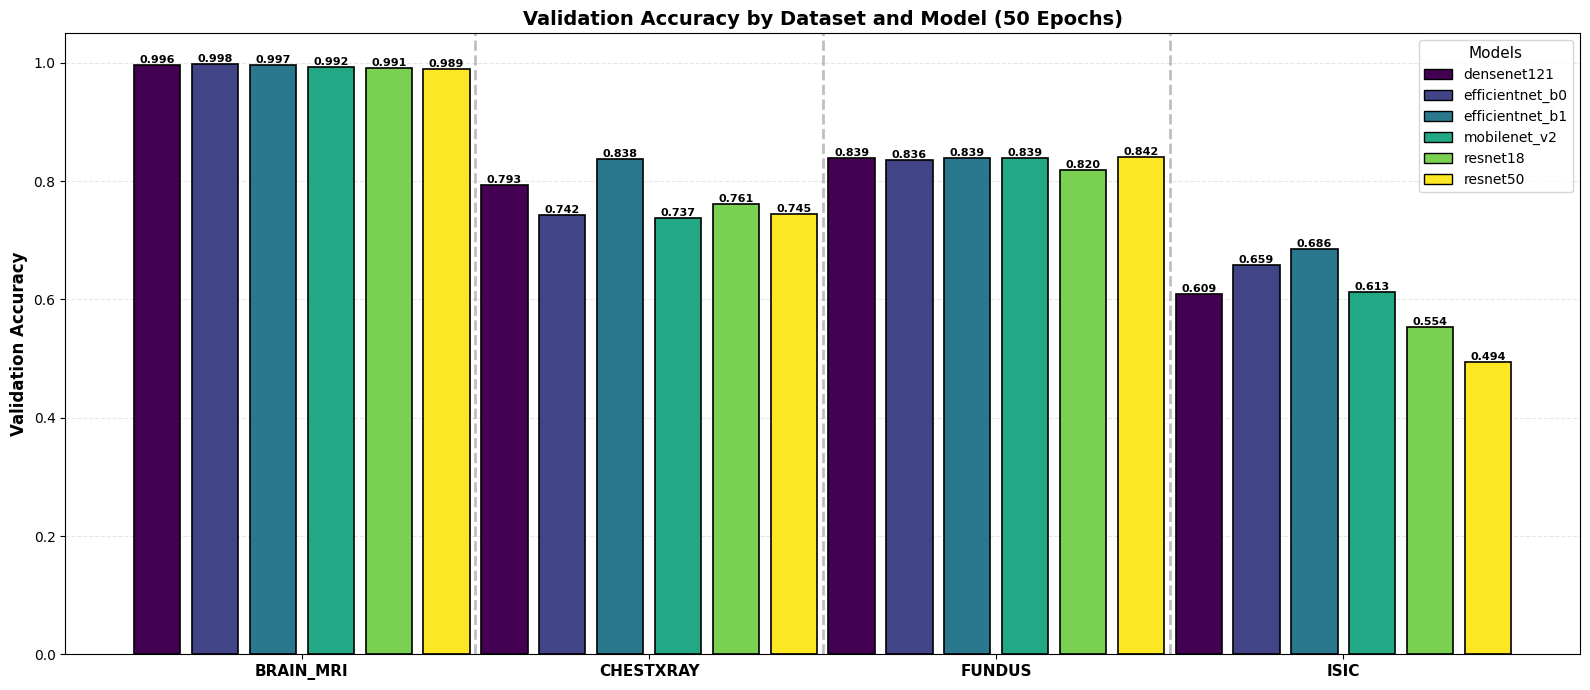


Validation Accuracy Summary by Dataset:

BRAIN_MRI:
  densenet121         : 0.9957
  efficientnet_b0     : 0.9985
  efficientnet_b1     : 0.9972
  mobilenet_v2        : 0.9923
  resnet18            : 0.9908
  resnet50            : 0.9889

CHESTXRAY:
  densenet121         : 0.7933
  efficientnet_b0     : 0.7420
  efficientnet_b1     : 0.8381
  mobilenet_v2        : 0.7372
  resnet18            : 0.7612
  resnet50            : 0.7452

FUNDUS:
  densenet121         : 0.8388
  efficientnet_b0     : 0.8361
  efficientnet_b1     : 0.8388
  mobilenet_v2        : 0.8388
  resnet18            : 0.8197
  resnet50            : 0.8415

ISIC:
  densenet121         : 0.6092
  efficientnet_b0     : 0.6590
  efficientnet_b1     : 0.6858
  mobilenet_v2        : 0.6130
  resnet18            : 0.5536
  resnet50            : 0.4943


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define the data structure
datasets = ['brain_mri', 'chestxray', 'fundus', 'isic']
models = ['densenet121', 'efficientnet_b0', 'efficientnet_b1', 'mobilenet_v2', 'resnet18', 'resnet50']

# Validation accuracy data for all combinations (collected from metrics.json)
val_accuracy_data = {
    'brain_mri': [0.9956909818405664, 0.9984610649430594, 0.997229916897507, 0.992305324715297, 0.9907663896583564, 0.9889196675900277],
    'chestxray': [0.7932692307692307, 0.7419871794871795, 0.8381410256410257, 0.7371794871794872, 0.7612179487179487, 0.7451923076923077],
    'fundus': [0.8387978142076503, 0.8360655737704918, 0.8387978142076503, 0.8387978142076503, 0.819672131147541, 0.8415300546448088],
    'isic': [0.6091954022988506, 0.6590038314176245, 0.685823754789272, 0.6130268199233716, 0.553639846743295, 0.4942528735632184]
}

# Create a list for plotting
plot_data = []
x_labels = []
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for dataset_idx, dataset in enumerate(datasets):
    for model_idx, model in enumerate(models):
        plot_data.append(val_accuracy_data[dataset][model_idx])
        x_labels.append(model)

# Create figure
fig, ax = plt.subplots(figsize=(16, 7))

# Create bar positions
x_positions = np.arange(len(plot_data))
bar_width = 0.8

# Create bars with color coding by model
model_colors = []
for i in range(len(plot_data)):
    model_idx = i % len(models)
    model_colors.append(colors[model_idx])

bars = ax.bar(x_positions, plot_data, bar_width, color=model_colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, plot_data)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Customize plot
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Validation Accuracy by Dataset and Model (50 Epochs)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

# Set x-axis ticks and labels
dataset_positions = []
dataset_labels = []
for i in range(len(datasets)):
    start_pos = i * len(models)
    end_pos = start_pos + len(models) - 1
    middle_pos = (start_pos + end_pos) / 2
    dataset_positions.append(middle_pos)
    dataset_labels.append(datasets[i].upper())

ax.set_xticks(dataset_positions)
ax.set_xticklabels(dataset_labels, fontsize=11, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Create legend for models
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=models[i]) 
                   for i in range(len(models))]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Models', title_fontsize=11)

# Add vertical separators between datasets
for i in range(1, len(datasets)):
    sep_x = i * len(models) - 0.5
    ax.axvline(x=sep_x, color='gray', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nValidation Accuracy Summary by Dataset:")
print("=" * 70)
for dataset in datasets:
    print(f"\n{dataset.upper()}:")
    for model, accuracy in zip(models, val_accuracy_data[dataset]):
        print(f"  {model:20s}: {accuracy:.4f}")


In [1]:
import json
from pathlib import Path
import pandas as pd

# Resolve project root by walking up until 'src' is found
start = Path.cwd()
project_root = None
for p in [start] + list(start.parents):
    if (p / "src").exists():
        project_root = p
        break
if project_root is None:
    project_root = start
    print(f"[WARN] Could not find repo root; using CWD={start}")
else:
    print(f"Using project_root={project_root}")

# Aggregate robustness pct_certified averaged across attribution methods
root = project_root / "outputs" / "eval" / "experiment1" / "robustness"
rows = []
for fp in sorted(root.glob("*/*/robustness_results.json")):
    dataset = fp.parents[1].name
    model = fp.parents[0].name
    obj = json.loads(fp.read_text())  # method -> k -> metrics
    for k in ["5", "25", "50"]:
        vals = []
        for method, km in obj.items():
            if k in km and "pct_certified" in km[k]:
                vals.append(km[k]["pct_certified"])
        if vals:
            rows.append({
                "dataset": dataset,
                "model": model,
                "k": int(k),
                "pct_certified_avg": sum(vals) / len(vals),
            })

if not rows:
    print("No robustness results found.")
else:
    df = pd.DataFrame(rows)
    df.sort_values(["dataset", "model", "k"], inplace=True)
    table = df.pivot(index=["dataset", "model"], columns="k", values="pct_certified_avg")
    display(table)

    # Save to CSV for reuse
    out_csv = project_root / "outputs" / "eval" / "experiment1" / "robustness_avg_by_model.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(out_csv)
    print(f"Saved: {out_csv}")


Using project_root=d:\git projects\certified-attribution-medical-imaging


k                                 5          25         50
dataset   model                                           
brain_mri densenet121      94.477519  62.353715  48.996413
          efficientnet_b1  92.126754  55.614955  42.680804
          mobilenet_v2     93.646365  64.800622  56.028380
          resnet18         93.280533  60.825574  50.734216
chestxray densenet121      91.236209  35.806840  25.003508
          efficientnet_b1  90.051818  50.904177  35.632972
          mobilenet_v2     89.865513  40.974011  24.369180
          resnet18         92.896445  49.708546  36.509008
fundus    densenet121      90.913026  32.324697  15.995934
          efficientnet_b1  89.730867  42.373166  26.464764
          mobilenet_v2     90.084263  43.257254  29.308753
          resnet18         79.947704  35.903938  30.639349
isic      densenet121      92.196508  41.565928  30.259407
          efficientnet_b1  88.523836  45.974330  36.722975
          mobilenet_v2     84.970982  44.854353  33.384008
          resnet18         89.836575  45.358578  31.965163

Saved: d:\git projects\certified-attribution-medical-imaging\outputs\eval\experiment1\robustness_avg_by_model.csv


In [2]:
# Format robustness table for sharing (rounded, markdown, LaTeX)
if 'table' not in locals():
    print("table not found; run the aggregation cell first.")
else:
    rounded = table.copy().round(3)
    display(rounded)

    # Markdown table
    md_table = rounded.reset_index().rename(columns={5: 'k=5', 25: 'k=25', 50: 'k=50'}).to_markdown(index=False)
    out_md = project_root / "outputs" / "eval" / "experiment1" / "robustness_avg_by_model.md"
    out_md.parent.mkdir(parents=True, exist_ok=True)
    out_md.write_text(md_table)
    print(f"Markdown saved: {out_md}")

    # LaTeX table (optional)
    latex_table = rounded.reset_index().rename(columns={5: 'k=5', 25: 'k=25', 50: 'k=50'}).to_latex(index=False)
    out_tex = project_root / "outputs" / "eval" / "experiment1" / "robustness_avg_by_model.tex"
    out_tex.write_text(latex_table)
    print(f"LaTeX saved: {out_tex}")


k                              5       25      50
dataset   model                                  
brain_mri densenet121      94.478  62.354  48.996
          efficientnet_b1  92.127  55.615  42.681
          mobilenet_v2     93.646  64.801  56.028
          resnet18         93.281  60.826  50.734
chestxray densenet121      91.236  35.807  25.004
          efficientnet_b1  90.052  50.904  35.633
          mobilenet_v2     89.866  40.974  24.369
          resnet18         92.896  49.709  36.509
fundus    densenet121      90.913  32.325  15.996
          efficientnet_b1  89.731  42.373  26.465
          mobilenet_v2     90.084  43.257  29.309
          resnet18         79.948  35.904  30.639
isic      densenet121      92.197  41.566  30.259
          efficientnet_b1  88.524  45.974  36.723
          mobilenet_v2     84.971  44.854  33.384
          resnet18         89.837  45.359  31.965

Markdown saved: d:\git projects\certified-attribution-medical-imaging\outputs\eval\experiment1\robustness_avg_by_model.md
LaTeX saved: d:\git projects\certified-attribution-medical-imaging\outputs\eval\experiment1\robustness_avg_by_model.tex


## Experiment 2: Robustness Aggregation (resnet18 only)


In [3]:
import json
from pathlib import Path
import pandas as pd

# Use same project_root from previous cell
if 'project_root' not in locals():
    start = Path.cwd()
    project_root = None
    for p in [start] + list(start.parents):
        if (p / "src").exists():
            project_root = p
            break
    if project_root is None:
        project_root = start

# Aggregate Experiment 2 robustness pct_certified averaged across attribution methods
root2 = project_root / "outputs" / "eval" / "experiment2" / "robustness"
rows2 = []
for fp in sorted(root2.glob("*/*/robustness_results.json")):
    dataset = fp.parents[1].name
    model = fp.parents[0].name
    obj = json.loads(fp.read_text())  # method -> k -> metrics
    for k in ["5", "25", "50"]:
        vals = []
        for method, km in obj.items():
            if k in km and "pct_certified" in km[k]:
                vals.append(km[k]["pct_certified"])
        if vals:
            rows2.append({
                "dataset": dataset,
                "model": model,
                "k": int(k),
                "pct_certified_avg": sum(vals) / len(vals),
            })

if not rows2:
    print("No robustness results found for Experiment 2.")
else:
    df2 = pd.DataFrame(rows2)
    df2.sort_values(["dataset", "model", "k"], inplace=True)
    table2 = df2.pivot(index=["dataset", "model"], columns="k", values="pct_certified_avg")
    display(table2)

    # Save to CSV for reuse
    out_csv2 = project_root / "outputs" / "eval" / "experiment2" / "robustness_avg_by_model.csv"
    out_csv2.parent.mkdir(parents=True, exist_ok=True)
    table2.to_csv(out_csv2)
    print(f"Saved: {out_csv2}")

,k,5,25,50
dataset,model,,,
brain_mri,resnet18,93.492180,61.313823,49.567311
chestxray,resnet18,92.258044,49.370037,36.804018
fundus,resnet18,76.691530,36.188819,29.825020
isic,resnet18,89.916906,41.990895,30.770800


Saved: d:\git projects\certified-attribution-medical-imaging\outputs\eval\experiment2\robustness_avg_by_model.csv


In [4]:
# Format Experiment 2 robustness table for sharing
if 'table2' not in locals():
    print("table2 not found; run the Experiment 2 aggregation cell first.")
else:
    rounded2 = table2.copy().round(3)
    display(rounded2)

    # Markdown table
    md_table2 = rounded2.reset_index().rename(columns={5: 'k=5', 25: 'k=25', 50: 'k=50'}).to_markdown(index=False)
    out_md2 = project_root / "outputs" / "eval" / "experiment2" / "robustness_avg_by_model.md"
    out_md2.parent.mkdir(parents=True, exist_ok=True)
    out_md2.write_text(md_table2)
    print(f"Markdown saved: {out_md2}")

    # LaTeX table
    latex_table2 = rounded2.reset_index().rename(columns={5: 'k=5', 25: 'k=25', 50: 'k=50'}).to_latex(index=False)
    out_tex2 = project_root / "outputs" / "eval" / "experiment2" / "robustness_avg_by_model.tex"
    out_tex2.write_text(latex_table2)
    print(f"LaTeX saved: {out_tex2}")

,k,5,25,50
dataset,model,,,
brain_mri,resnet18,93.492,61.314,49.567
chestxray,resnet18,92.258,49.370,36.804
fundus,resnet18,76.692,36.189,29.825
isic,resnet18,89.917,41.991,30.771


Markdown saved: d:\git projects\certified-attribution-medical-imaging\outputs\eval\experiment2\robustness_avg_by_model.md
LaTeX saved: d:\git projects\certified-attribution-medical-imaging\outputs\eval\experiment2\robustness_avg_by_model.tex
